# **Lesson_6.1**

## In this lecture

* Fork repository

* Decision tree
* In-class exercise

---

## Decision Tree ML model

A **decision tree** (in simple words) represents a hierarchical series of binary decisions:

<p align="center">
	<img src="../assets/img/decision_tree.jpg" width="600">
</p>

* A decision tree in machine learning works in exactly the same way, and except that we let the computer figure out the optimal structure & hierarchy of decisions, instead of coming up with criteria manually

## Who would survive on Titanic?
<p align="center">
	<img src='../assets/img/decision_tree_titanic.jpg' width = '500'>
</p>

#### Import libraries and modules

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.tree import plot_tree, export_text
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import itertools


#### Load Titanic dataset

In [ ]:
# We use url, but can also download and access it locally
dataset_path = 'https://raw.githubusercontent.com/Koldim2001/test_api/refs/heads/main/titanic.csv' 
df = pd.read_csv(dataset_path)

#### Let's have a look at the dataset

In [ ]:
df.head()

In [ ]:
df.info()

In [ ]:
df.describe()

#### Select features
* We only select `Pclass`, `Age` and `Fare` features for the sake of demonstration of the model
* Maximising model prediction accuracy was not a goal of the present exercise
* In particular, we do not *one-hot* encode categorical features. Feel free to add hot-encoded features and see how prediction accuracy can be affected
* `Survived` column will be our **target**

In [ ]:
df = df[['Survived', 'Pclass', 'Age', 'Fare']]  # The subset (columns) we selected for this project
df.info()

#### Data cleaning: drop lines where `Age`data are not available

In [ ]:
df = df.dropna(subset=['Age'])

In [ ]:
df.info()

In [ ]:
df.isna().sum()

In [ ]:
df.drop(columns='Survived')  # These are our features

#### Split dataset

In [ ]:
# Splitdataset
train, test = train_test_split(df, test_size=0.2)

#### Build a helper function to plot Confusion Matrix

In [ ]:
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    Plots confusion matrix
    cm - confusion matrix
    classes - class list
    normalize - normalize to 1 if True
    title - plot title
    cmap - color map
    """

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

#### Helper function to build and train Decision Tree model

In [ ]:
def experiment(max_depth, min_samples_split):
    """
    Builds and trains Decision Tree model
    """
    # Build and train Decision Tree model
    model = DecisionTreeClassifier(max_depth=max_depth, min_samples_split=min_samples_split, random_state=42)
    model.fit(train.drop('Survived', axis=1), train['Survived'])

    # Calculate accuracy metrics
    preds = model.predict(test.drop('Survived', axis=1))
    acc = accuracy_score(test['Survived'], preds)
    cm = confusion_matrix(test['Survived'], preds)

    print("accuracy", acc)

    # Plot confusion matrix
    plot_confusion_matrix(cm, classes=['Not Survived', 'Survived'])

    # Classification report
    report = classification_report(test['Survived'], preds, target_names=['Not Survived', 'Survived'])
    print(report)

    # Save model in pickle format
    with open('../models/model_dt.pkl', 'wb') as f:
        pickle.dump(model, f)
        

#### Define model <u>hyperparameters</u>

In [ ]:
# Define model hyperparameters
max_depth = 5
min_samples_split = 150


In [ ]:
experiment(max_depth, min_samples_split)

#### Prediction for a single person

In [ ]:
with open('../models/model_dt.pkl', 'rb') as f:
    model = pickle.load(f)

In [ ]:
# Predict outcome of Titanic trip for a person
person = pd.DataFrame({
	'Pclass':[3],
	'Age':[55],
	'Fare':[7.2500]	
})

prediction = model.predict(person)
print(f"The model predicts {prediction}")

In [ ]:
if prediction == [1]:
    print ("This person is, the most likely, is a survivor.")
else:
    print("This person, the most likely, perished.")

#### Again: what is the Decision Tree in the context of ML?

In [ ]:
plt.figure(figsize=(80,20))
plot_tree(model, feature_names=df.drop(columns='Survived').columns, max_depth=5, filled=True)


* Can you see how the model classifies a given input as a series of decisions?
* The tree is following any path from the root node down to a leaf will result in "Yes" or "No"

**How a Decision Tree is Created**

* Note the `gini` value in each box
* This is the loss function used by the decision tree to decide which column should be used for splitting the data, and at what point the column should be split
* A lower Gini index indicates a better split
* A perfect split (only one class on each side) has a Gini index of 0
* Conceptually speaking, while training the models evaluates all possible splits across all possible columns and picks the best one
* Then, it recursively performs an optimal split for the two portions


#### Textual representation of our Decision Tree model

In [ ]:
tree_text = export_text(model, max_depth=5, feature_names=df.drop(columns='Survived').columns)
print(tree_text)

#### Feature importance

In [ ]:
importance_df = pd.DataFrame({
    'feature': df.drop(columns='Survived').columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)
plt.title('Feature Importance')
sns.barplot(data=importance_df.head(10), x='importance', y='feature', hue='importance')
plt.show()

### Hyperparameters, Underfitting and Overfitting
* Our decision tree classifier can memorise all training examples, leading to a 100% training accuracy (just like a student who memorised all possible exam answers)
* Yet validation accuracy will be very poor due to poor **generalisation**
* This phenomenon is called **overfitting**, and in this section, we'll have a closer look at it
* The `DecisionTreeClassifier` is a suitable model to demonstrate overfitting
* Overfitting is much more common than underfitting
* This is a common pattern you'll see with all machine learning algorithms:
<p align="center">
<img src="../assets/img/overfitting_vs_underfitting.jpg" width="600">
</p>


#### `max_depth` optimisation (example)

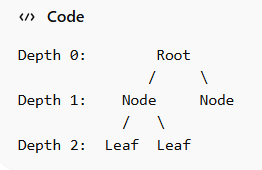

Maximum depth is:
* The maximum number of splits from the root to the deepest leaf
Or more formally:
* The longest path from the root node down to a leaf node

*Root = depth 0*

*First split = depth 1*

*Next split = depth 2*

*If the deepest leaf is at depth 2 → max_depth = 2.*

In [ ]:
def max_depth_error(md):
    """
    Returns training and validation (test) accuracy as a function of tree maximum depth
    """
    model = DecisionTreeClassifier(max_depth=md, random_state=42)
    model.fit(train.drop(columns='Survived'), train['Survived'])
    train_acc = 1 - model.score(train.drop(columns='Survived'), train['Survived'])
    test_acc = 1 - model.score(test.drop(columns='Survived'), test['Survived'])
    return {'Max Depth': md, 'Training Error': train_acc, 'Test Error': test_acc}

In [ ]:
errors_list = []

for md in range(1, 21):
    result = max_depth_error(md)
    errors_list.append(result)

errors_df = pd.DataFrame(errors_list)

In [ ]:
# errors_df
errors_df

In [ ]:
plt.figure()
plt.scatter(errors_df['Max Depth'], errors_df['Training Error'])
plt.plot(errors_df['Max Depth'], errors_df['Test Error'])
plt.title('Training vs. Validation Error')
plt.xticks(range(0,21, 2))
plt.xlabel('Max. Depth')
plt.ylabel('Prediction Error (1 - Accuracy)')
plt.legend(['Training', 'Validation'])
plt.show()

In [ ]:
?DecisionTreeClassifier

In [ ]:
model

---

## In-class exercise

---

##### Reminder: do not forget to **Clear All Outputs**
### Now you can commit and push your code to **GitHub**